<a href="https://colab.research.google.com/github/Suhrobjonibodullayev/Mini-projects/blob/main/Titanic%26Airbnb_dataset_EDA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

Topshiriq 1

In [ ]:
df = pd.read_csv("https://raw.githubusercontent.com/mwaskom/seaborn-data/master/titanic.csv")

df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [ ]:
# umumiy malumotlar nan qiymatlar , ustunlar dtype qator va ustunlar sonini ko'rish
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   survived     891 non-null    int64  
 1   pclass       891 non-null    int64  
 2   sex          891 non-null    object 
 3   age          714 non-null    float64
 4   sibsp        891 non-null    int64  
 5   parch        891 non-null    int64  
 6   fare         891 non-null    float64
 7   embarked     889 non-null    object 
 8   class        891 non-null    object 
 9   who          891 non-null    object 
 10  adult_male   891 non-null    bool   
 11  deck         203 non-null    object 
 12  embark_town  889 non-null    object 
 13  alive        891 non-null    object 
 14  alone        891 non-null    bool   
dtypes: bool(2), float64(2), int64(4), object(7)
memory usage: 92.4+ KB


In [ ]:
# sonli ustunlarni ko'rish
df.select_dtypes(include="number")

,survived,pclass,age,sibsp,parch,fare
0,0,3,22.0,1,0,7.2500
1,1,1,38.0,1,0,71.2833
2,1,3,26.0,0,0,7.9250
3,1,1,35.0,1,0,53.1000
4,0,3,35.0,0,0,8.0500
...,...,...,...,...,...,...
886,0,2,27.0,0,0,13.0000
887,1,1,19.0,0,0,30.0000
888,0,3,NaN,1,2,23.4500
889,1,1,26.0,0,0,30.0000


In [ ]:
df['sex'].dtypes # obect harfli ustun
df["age"].dtypes # float sonli ustun

dtype('float64')

In [ ]:
df.select_dtypes(include="object")

,sex,embarked,class,who,deck,embark_town,alive
0,male,S,Third,man,NaN,Southampton,no
1,female,C,First,woman,C,Cherbourg,yes
2,female,S,Third,woman,NaN,Southampton,yes
3,female,S,First,woman,C,Southampton,yes
4,male,S,Third,man,NaN,Southampton,no
...,...,...,...,...,...,...,...
886,male,S,Second,man,NaN,Southampton,no
887,female,S,First,woman,B,Southampton,yes
888,female,S,Third,woman,NaN,Southampton,no
889,male,C,First,man,C,Cherbourg,yes


In [ ]:
df.dtypes.value_counts()

,count
object,7
int64,4
float64,2
bool,2


7 ta object ustun bor , 8 ta sonli -> 4 int, 2 ta float , 2 bool

Topsiriq 2

In [ ]:
df2 = df.copy() # dfdan nusxa olish

In [ ]:
df2.drop("deck", axis=1, inplace=True) # ustunni o'chirish
df2.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,Southampton,no,True


In [ ]:
df2.dropna(subset=["embarked"], inplace=True) # embarket ustunidagi bosh qatorlarni tashlab yuboramaiz

In [ ]:
df2["age"].fillna(np.mean(df2["age"]), inplace=True) # mean qiymat bilan to'ldiramiz

/tmp/ipykernel_803/2427382356.py:1: FutureWarning:

A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.





In [ ]:
df2.isnull().sum() # bo'sh qiymatlar qolmadi

,0
survived,0
pclass,0
sex,0
age,0
sibsp,0
parch,0
fare,0
embarked,0
class,0
who,0


In [ ]:
df2.shape # 889 ta qator qoldi

(889, 14)

topshiriq 3

Text(0.5, 1.0, 'Yosh taqsimoti')

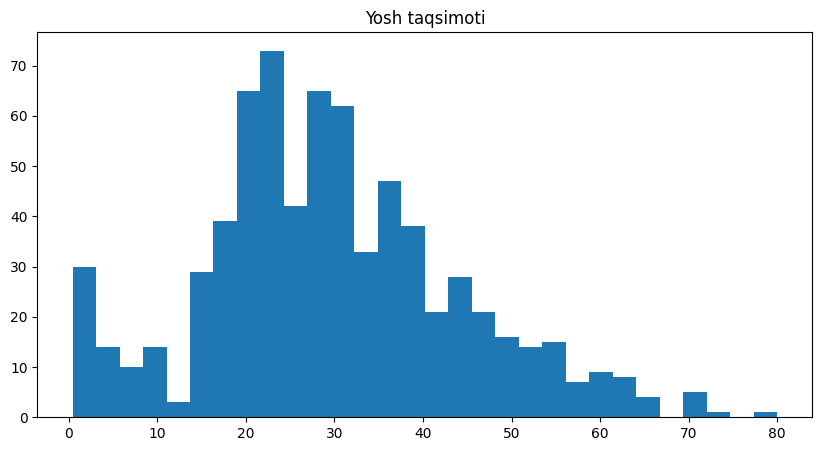

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))

plt.hist(df['age'].dropna(), bins=30)
plt.title('Yosh taqsimoti')

In [ ]:
Q1, Q3 = df['age'].quantile([0.25, 0.75])
IQR = Q3 - Q1
outliers = df[df['age'] > Q3 + 1.5 * IQR]
outliers2 = df[df['age'] < Q1 - 1.5 * IQR]
outliers.shape[0] + outliers2.shape[0] # umumiy 11 ta outlier bor

11

In [ ]:
df['family'] = df['sibsp'] + df['parch']+1 # family ustuni yaratamiz
df.head(4)

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone,family
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False,2
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False,2
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True,1
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False,2


In [ ]:
df['family'].value_counts() # family ustunini ko'rish 1 eng ko'p takrorlangan

,count
family,
1,537
2,161
3,102
4,29
6,22
5,15
7,12
11,7
8,6


Topshiriq 4

In [ ]:
# df.reset_index(inplace=True) index ustunini qaytarish

In [ ]:
df.groupby('embarked')['survived'].mean() * 100 # eng ko'p C dan chiqqanlar 55 foiz

,survived
embarked,
C,55.357143
Q,38.961039
S,33.695652


In [ ]:
df.pivot_table(
    values='survived',
    index='embarked',
    columns='pclass',
    aggfunc='mean'
) * 100

pclass,1,2,3
embarked,,,
C,69.411765,52.941176,37.878788
Q,50.000000,66.666667,37.500000
S,58.267717,46.341463,18.980170


In [ ]:
pd.crosstab(df['embarked'], df['pclass']) # Pclass 1 > Pclass 2 > Pclass 3 | C > Q > S

pclass,1,2,3
embarked,,,
C,85,17,66
Q,2,3,72
S,127,164,353


In [ ]:
bins = [0, 12, 18, 35, 60, 100]

labels = ['0-12', '12-18', '18-35', '35-60', '60-100']

df['AgeGroup'] = pd.cut(
    df['age'],
    bins=bins,
    labels=labels
)
df["AgeGroup"].value_counts()

,count
AgeGroup,
18-35,358
35-60,195
12-18,70
0-12,69
60-100,22


In [ ]:
df.groupby('AgeGroup', observed=True)['survived'].mean() * 100

,survived
AgeGroup,
0-12,57.971014
12-18,42.857143
18-35,38.268156
35-60,40.000000
60-100,22.727273


In [ ]:
survival_rate = (
    df.groupby('AgeGroup', observed=True)['survived'].mean().mul(100).round(2)
)

survival_rate

,survived
AgeGroup,
0-12,57.97
12-18,42.86
18-35,38.27
35-60,40.00
60-100,22.73


In [ ]:
df['TravelType'] = np.where(
    df['family'] == 1,
    'Yolgiz',
    'Oila bilan'
)

df.groupby('TravelType')['survived'].mean().mul(100).round(2).reset_index()

,TravelType,survived
0,Oila bilan,50.56
1,Yolgiz,30.35


### 7 qatlamli cheklist

KO'pchiligi bajarilgan faqat describe va corr qolgan ekan

In [ ]:
df.describe() # raqamli ustunlar statistik malumotlari

,survived,pclass,age,sibsp,parch,fare,family
count,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000,891.000000
mean,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208,1.904602
std,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429,1.613459
min,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000,1.000000
25%,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400,1.000000
50%,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200,1.000000
75%,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000,2.000000
max,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200,11.000000


In [ ]:
df.corr(numeric_only=True) # correlation ni ko'rish

,survived,pclass,age,sibsp,parch,fare,adult_male,alone,family
survived,1.000000,-0.338481,-0.077221,-0.035322,0.081629,0.257307,-0.557080,-0.203367,0.016639
pclass,-0.338481,1.000000,-0.369226,0.083081,0.018443,-0.549500,0.094035,0.135207,0.065997
age,-0.077221,-0.369226,1.000000,-0.308247,-0.189119,0.096067,0.280328,0.198270,-0.301914
sibsp,-0.035322,0.083081,-0.308247,1.000000,0.414838,0.159651,-0.253586,-0.584471,0.890712
parch,0.081629,0.018443,-0.189119,0.414838,1.000000,0.216225,-0.349943,-0.583398,0.783111
fare,0.257307,-0.549500,0.096067,0.159651,0.216225,1.000000,-0.182024,-0.271832,0.217138
adult_male,-0.557080,0.094035,0.280328,-0.253586,-0.349943,-0.182024,1.000000,0.404744,-0.348143
alone,-0.203367,0.135207,0.198270,-0.584471,-0.583398,-0.271832,0.404744,1.000000,-0.690922
family,0.016639,0.065997,-0.301914,0.890712,0.783111,0.217138,-0.348143,-0.690922,1.000000


In [ ]:
df.corrwith(df["survived"], numeric_only=True) # survivedga nisbatan correlation ni ko'rish

,0
survived,1.000000
pclass,-0.338481
age,-0.077221
sibsp,-0.035322
parch,0.081629
fare,0.257307
adult_male,-0.557080
alone,-0.203367
family,0.016639


### 4 ta grafik qo'shish , Histogram, Boxplot,heatmap ,pie , bar

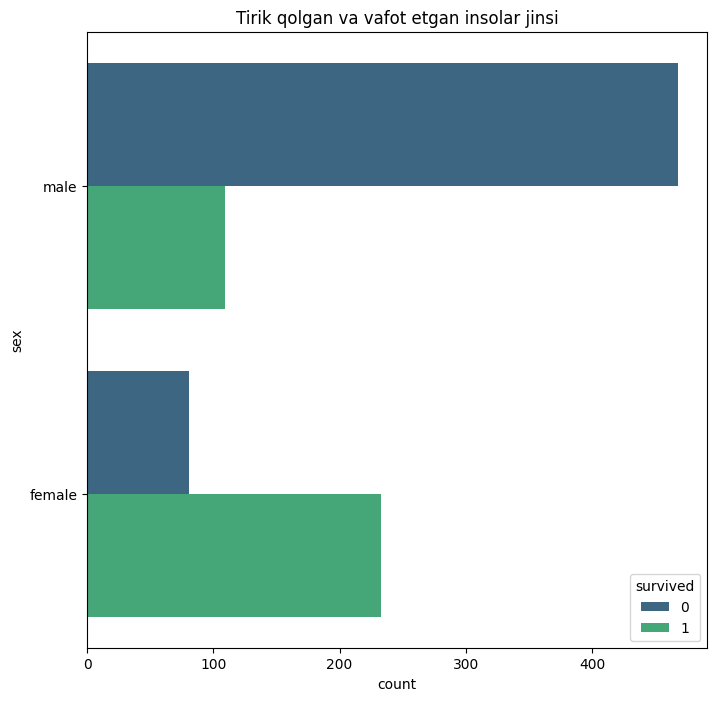

In [ ]:
plt.figure(figsize=(8,8))

sns.countplot(y='sex', hue='survived', palette='viridis', data=df)
plt.title("Tirik qolgan va vafot etgan insolar jinsi")

plt.show()

In [ ]:
fig = px.histogram(
    df,
    x="age",
    color_discrete_sequence=['crimson'],
    template='plotly_dark',
    marginal="box", # Box, Violin yoki Rug qo'shadi
    histfunc="count", # Bin ichidagi statistik funksiyani tanlaydi.
    histnorm="percent", # Histogramni normallashtiradi.
    nbins=20, # Binlar sonini belgilaydi.
    barnorm="percent", # Ustunlarni foiz yoki ulushga o'tkazadi.
    barmode="overlay",
    opacity=0.7,
    width=800,
    height=500
)

fig.show()

In [ ]:
fig = px.box(
    df,
    x="age",
    color="sex",
    color_discrete_sequence=['crimson', 'teal'],
    template='plotly_dark',
    notched=True
)

fig.show()

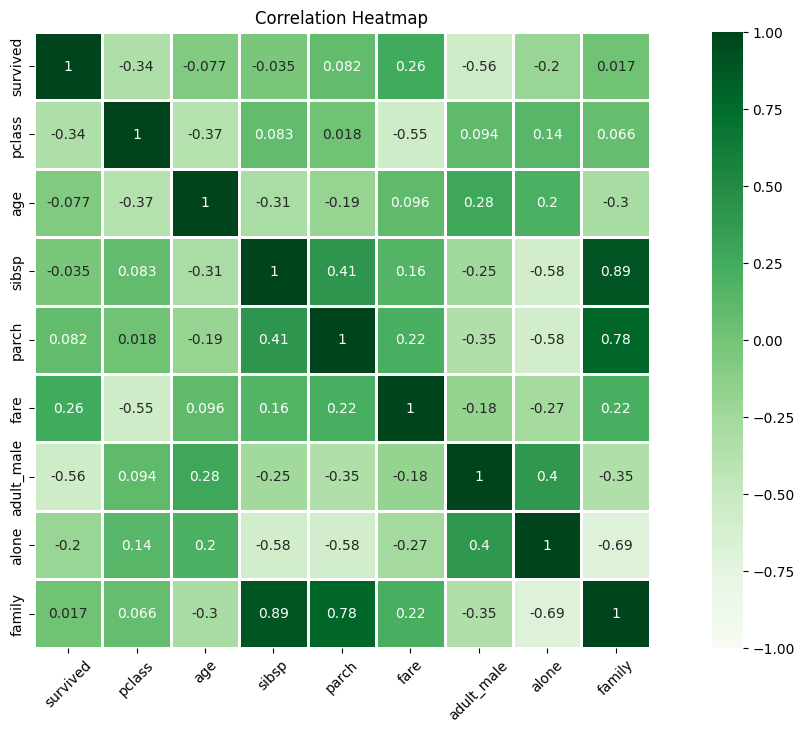

In [ ]:
plt.figure(figsize=(16,8))

sns.heatmap(data=df.corr(numeric_only=True),
            cmap="Greens",
            linewidths=1,
            annot=True, # annot	Kataklarda raqamni yozish (True yoki False)
            vmax=1,
            vmin=-1,
            center=0,
            square=True)

plt.title("Correlation Heatmap")
plt.xticks(rotation=45)
plt.show()

In [ ]:
fig = px.pie(
    df,
    names="survived",# Sektor (bo'lak) nomlarini belgilaydi.
    color_discrete_sequence=px.colors.sequential.RdBu, #
    template='plotly_dark',
    labels={
        "Tirik": "Tirik qolganlar",
        "Vafot etgan": "Vafot etganlar"
    },
    #hole=0.5, # Donut Chart hosil qiladi.
    width=800,
    height=500
)

fig.show()

Oxirgi qism yangi dataset yuklab EDA qilish uchun Airbnb datasetini tanladim

In [ ]:
import pandas as pd

url = "https://raw.githubusercontent.com/pjournal/boun01g-data-mine-r-s/gh-pages/Assignment/AB_NYC_2019.csv"

df = pd.read_csv(url)

df.head(3)

,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365
0,2539,Clean & quiet apt home by the park,2787,John,Brooklyn,Kensington,40.64749,-73.97237,Private room,149,1,9,2018-10-19,0.21,6,365
1,2595,Skylit Midtown Castle,2845,Jennifer,Manhattan,Midtown,40.75362,-73.98377,Entire home/apt,225,1,45,2019-05-21,0.38,2,355
2,3647,THE VILLAGE OF HARLEM....NEW YORK !,4632,Elisabeth,Manhattan,Harlem,40.80902,-73.94190,Private room,150,3,0,NaN,NaN,1,365


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

In [ ]:
df.shape # qator va ustunlar soni

(48895, 16)

In [ ]:
# umumiy malumotlar nan qiymatlar , ustunlar dtype qator va ustunlar sonini ko'rish
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48895 entries, 0 to 48894
Data columns (total 16 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   id                              48895 non-null  int64  
 1   name                            48879 non-null  object 
 2   host_id                         48895 non-null  int64  
 3   host_name                       48874 non-null  object 
 4   neighbourhood_group             48895 non-null  object 
 5   neighbourhood                   48895 non-null  object 
 6   latitude                        48895 non-null  float64
 7   longitude                       48895 non-null  float64
 8   room_type                       48895 non-null  object 
 9   price                           48895 non-null  int64  
 10  minimum_nights                  48895 non-null  int64  
 11  number_of_reviews               48895 non-null  int64  
 12  last_review                     

In [ ]:
df.dtypes.value_counts() # 6 ta object ustun bor , 10 ta sonli -> 7 int, 3ta float

,count
int64,7
object,6
float64,3


In [ ]:
df.isnull().sum().sort_values(ascending=False) # tushib qolgan malumotlarni ko'rish

,0
last_review,10052
reviews_per_month,10052
host_name,21
name,16
neighbourhood_group,0
neighbourhood,0
id,0
host_id,0
longitude,0
latitude,0


In [ ]:
df.duplicated().sum() # takrorlangan qatorlar yo'q ekan

np.int64(0)

In [ ]:
# raqamli ustunlar statistikasini ko'rish

df.describe()

,id,host_id,latitude,longitude,price,minimum_nights,number_of_reviews,reviews_per_month,calculated_host_listings_count,availability_365
count,4.889500e+04,4.889500e+04,48895.000000,48895.000000,48895.000000,48895.000000,48895.000000,38843.000000,48895.000000,48895.000000
mean,1.901714e+07,6.762001e+07,40.728949,-73.952170,152.720687,7.029962,23.274466,1.373221,7.143982,112.781327
std,1.098311e+07,7.861097e+07,0.054530,0.046157,240.154170,20.510550,44.550582,1.680442,32.952519,131.622289
min,2.539000e+03,2.438000e+03,40.499790,-74.244420,0.000000,1.000000,0.000000,0.010000,1.000000,0.000000
25%,9.471945e+06,7.822033e+06,40.690100,-73.983070,69.000000,1.000000,1.000000,0.190000,1.000000,0.000000
50%,1.967728e+07,3.079382e+07,40.723070,-73.955680,106.000000,3.000000,5.000000,0.720000,1.000000,45.000000
75%,2.915218e+07,1.074344e+08,40.763115,-73.936275,175.000000,5.000000,24.000000,2.020000,2.000000,227.000000
max,3.648724e+07,2.743213e+08,40.913060,-73.712990,10000.000000,1250.000000,629.000000,58.500000,327.000000,365.000000


In [ ]:
df['minimum_nights'].value_counts()

,count
minimum_nights,
1,12720
2,11696
3,7999
30,3760
4,3303
...,...
275,1
182,1
114,1


In [ ]:
# raqamli ustunlar uchun correlationni ko'ramiz

df.corr(numeric_only=True)

,id,host_id,latitude,longitude,price,minimum_nights,number_of_reviews,reviews_per_month,calculated_host_listings_count,availability_365
id,1.000000,0.588290,-0.003125,0.090908,0.010619,-0.013224,-0.319760,0.291828,0.133272,0.085468
host_id,0.588290,1.000000,0.020224,0.127055,0.015309,-0.017364,-0.140106,0.296417,0.154950,0.203492
latitude,-0.003125,0.020224,1.000000,0.084788,0.033939,0.024869,-0.015389,-0.010142,0.019517,-0.010983
longitude,0.090908,0.127055,0.084788,1.000000,-0.150019,-0.062747,0.059094,0.145948,-0.114713,0.082731
price,0.010619,0.015309,0.033939,-0.150019,1.000000,0.042799,-0.047954,-0.030608,0.057472,0.081829
minimum_nights,-0.013224,-0.017364,0.024869,-0.062747,0.042799,1.000000,-0.080116,-0.121702,0.127960,0.144303
number_of_reviews,-0.319760,-0.140106,-0.015389,0.059094,-0.047954,-0.080116,1.000000,0.549868,-0.072376,0.172028
reviews_per_month,0.291828,0.296417,-0.010142,0.145948,-0.030608,-0.121702,0.549868,1.000000,-0.009421,0.185791
calculated_host_listings_count,0.133272,0.154950,0.019517,-0.114713,0.057472,0.127960,-0.072376,-0.009421,1.000000,0.225701
availability_365,0.085468,0.203492,-0.010983,0.082731,0.081829,0.144303,0.172028,0.185791,0.225701,1.000000


In [ ]:
# nan qiymatlar bilan to'ldiramiz

df = df.fillna({
    "last_review": "NaN",
    "reviews_per_month": "NaN"
})

In [ ]:
df = df.dropna(subset=["name", "host_name"]) # tushub qolgan qatorlar kam bo'lganini tashlab yuboramiz

In [ ]:
df.isnull().sum() # bo'sh qiymatlar qolmadi

,0
id,0
name,0
host_id,0
host_name,0
neighbourhood_group,0
neighbourhood,0
latitude,0
longitude,0
room_type,0
price,0


In [ ]:
fig = px.histogram(
    df,
    x="neighbourhood",
    color_discrete_sequence=['gold'],
    template='plotly_dark',
    marginal="box", # Box, Violin yoki Rug qo'shadi
    histfunc="count", # Bin ichidagi statistik funksiyani tanlaydi.
    histnorm="percent", # Histogramni normallashtiradi.
    nbins=20, # Binlar sonini belgilaydi.
    barnorm="percent", # Ustunlarni foiz yoki ulushga o'tkazadi.
    barmode="overlay",
    opacity=0.7,
    width=800,
    height=500
)

fig.show()

In [ ]:
fig = px.scatter(
    df,
    x="latitude",
    y="longitude",
    color_discrete_sequence = ["teal"],
    size_max=16, # nuqta hajmi max qancha bo'lishi mumkinligini chegarasi.
    title="latitude va longitude bog'liqlik", # sarlavha
    template='plotly_dark', # orqa fonni dark qilish
    trendline= "ols", # line chizish 'lowess', 'rolling', 'ewm', 'expanding', 'ols'
    trendline_scope="trace",
    #facet_col="species", # Grafikni guruhlash uchun
    width=900, # eni
    height=600 # bo'yi
)

fig.show()

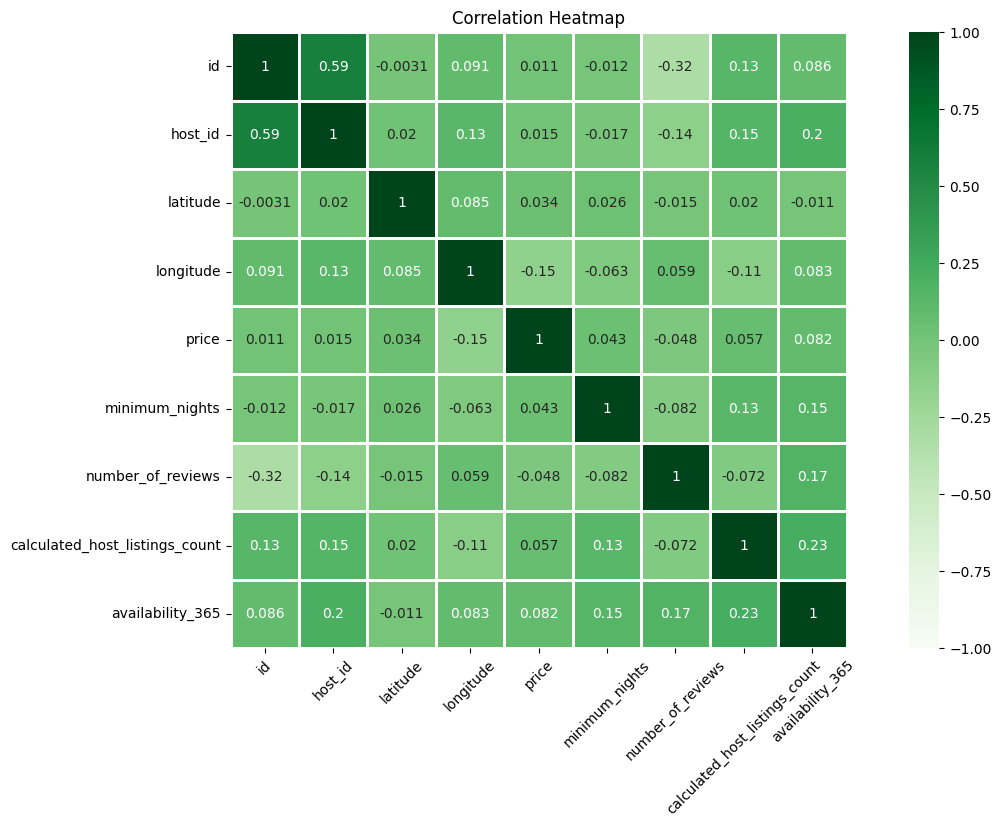

In [ ]:
plt.figure(figsize=(16,8))

sns.heatmap(data=df.corr(numeric_only=True),
            cmap="Greens",
            linewidths=1,
            annot=True, # annot	Kataklarda raqamni yozish (True yoki False)
            vmax=1,
            vmin=-1,
            center=0,
            square=True)

plt.title("Correlation Heatmap")
plt.xticks(rotation=45)
plt.show()

In [ ]:
fig = px.box(
    df,
    x="room_type",
    template='plotly_dark',
    notched=True
)

fig.show()